<a href="https://colab.research.google.com/github/Matheus0820/Aprendizado-de-Maquina/blob/main/unidade01/codes/Classificando_classes_de_pessoas_com_K_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means - Classificando classes de pessoas com K-means

Aprendizado de Máquina 26.1

**Aluno:** Matheus Ramos Ferreira da Silva

## Importando base de dados

In [19]:
# Bibliotecas
import pandas as pd

# URL da base de dados
url = 'https://raw.githubusercontent.com/ect-info/ml/master/dados/customer%20segmentation%20data.csv'

# Criando DataFrame
df = pd.read_csv(url)

# Visualizando DataFrame
df.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1


## Fazendo a separação dos dados

### Colunas escolhidas
- Age;
- Income;


In [20]:
# Colunas selecionadas
cols_selected = ['Age', 'Income']

# Criando X com esses dados
X = df[cols_selected].values

# Primeiras 5 linhas de X
X[:5]

array([[    67, 124670],
       [    22, 150773],
       [    49,  89210],
       [    45, 171565],
       [    53, 149031]])

## Normalizando os dados

In [21]:
# Biblioteca
from sklearn.preprocessing import MinMaxScaler

# Criando o scaler
scaler = MinMaxScaler()

# Aplicando o scaler
X = scaler.fit_transform(X)

# Mostrando as primeiras 5 linhas o X depois da normalização
print(X[:5])

[[0.84482759 0.32478101]
 [0.06896552 0.42021043]
 [0.53448276 0.19514353]
 [0.46551724 0.49622348]
 [0.60344828 0.41384189]]


## Treinamento

In [22]:
# Biblioteca
from sklearn.cluster import KMeans

# Número de clusteres no nosso modelo
n_clusters = 5

# Treinando modelo com os valores de X
kmeans = KMeans(n_clusters = n_clusters)
kmeans.fit(X)

# Rótulos dos clusters
labels = kmeans.labels_

# Centroides de cadas clusters
centroids = kmeans.cluster_centers_ # São calculados como os pontos médios entre os pontos dentro de um cluster

# Mostrando os rotulos e centroides
print(f"Rotulos: \n{labels}\n ")
print(f"Centroides: \n{centroids}\n ")

Rotulos: 
[2 0 1 ... 3 0 0]
 
Centroides: 
[[0.12980769 0.23669303]
 [0.51407682 0.32293294]
 [0.76555805 0.4551686 ]
 [0.30709695 0.25277617]
 [0.27077347 0.50339049]]
 


## Visualização do treinamento

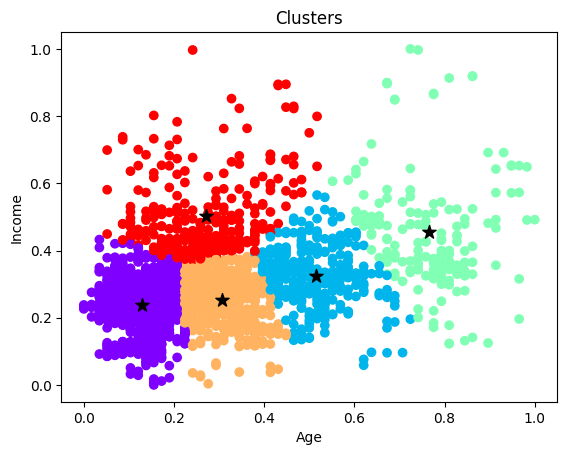

In [23]:
# Biblioteca
import matplotlib.pyplot as plt

# Plotando os dados
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', s=100, linewidths=1, color = 'black')
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Clusters')
plt.show()

## Visualizando Caracteristicas do centroides em um gráfico de barras

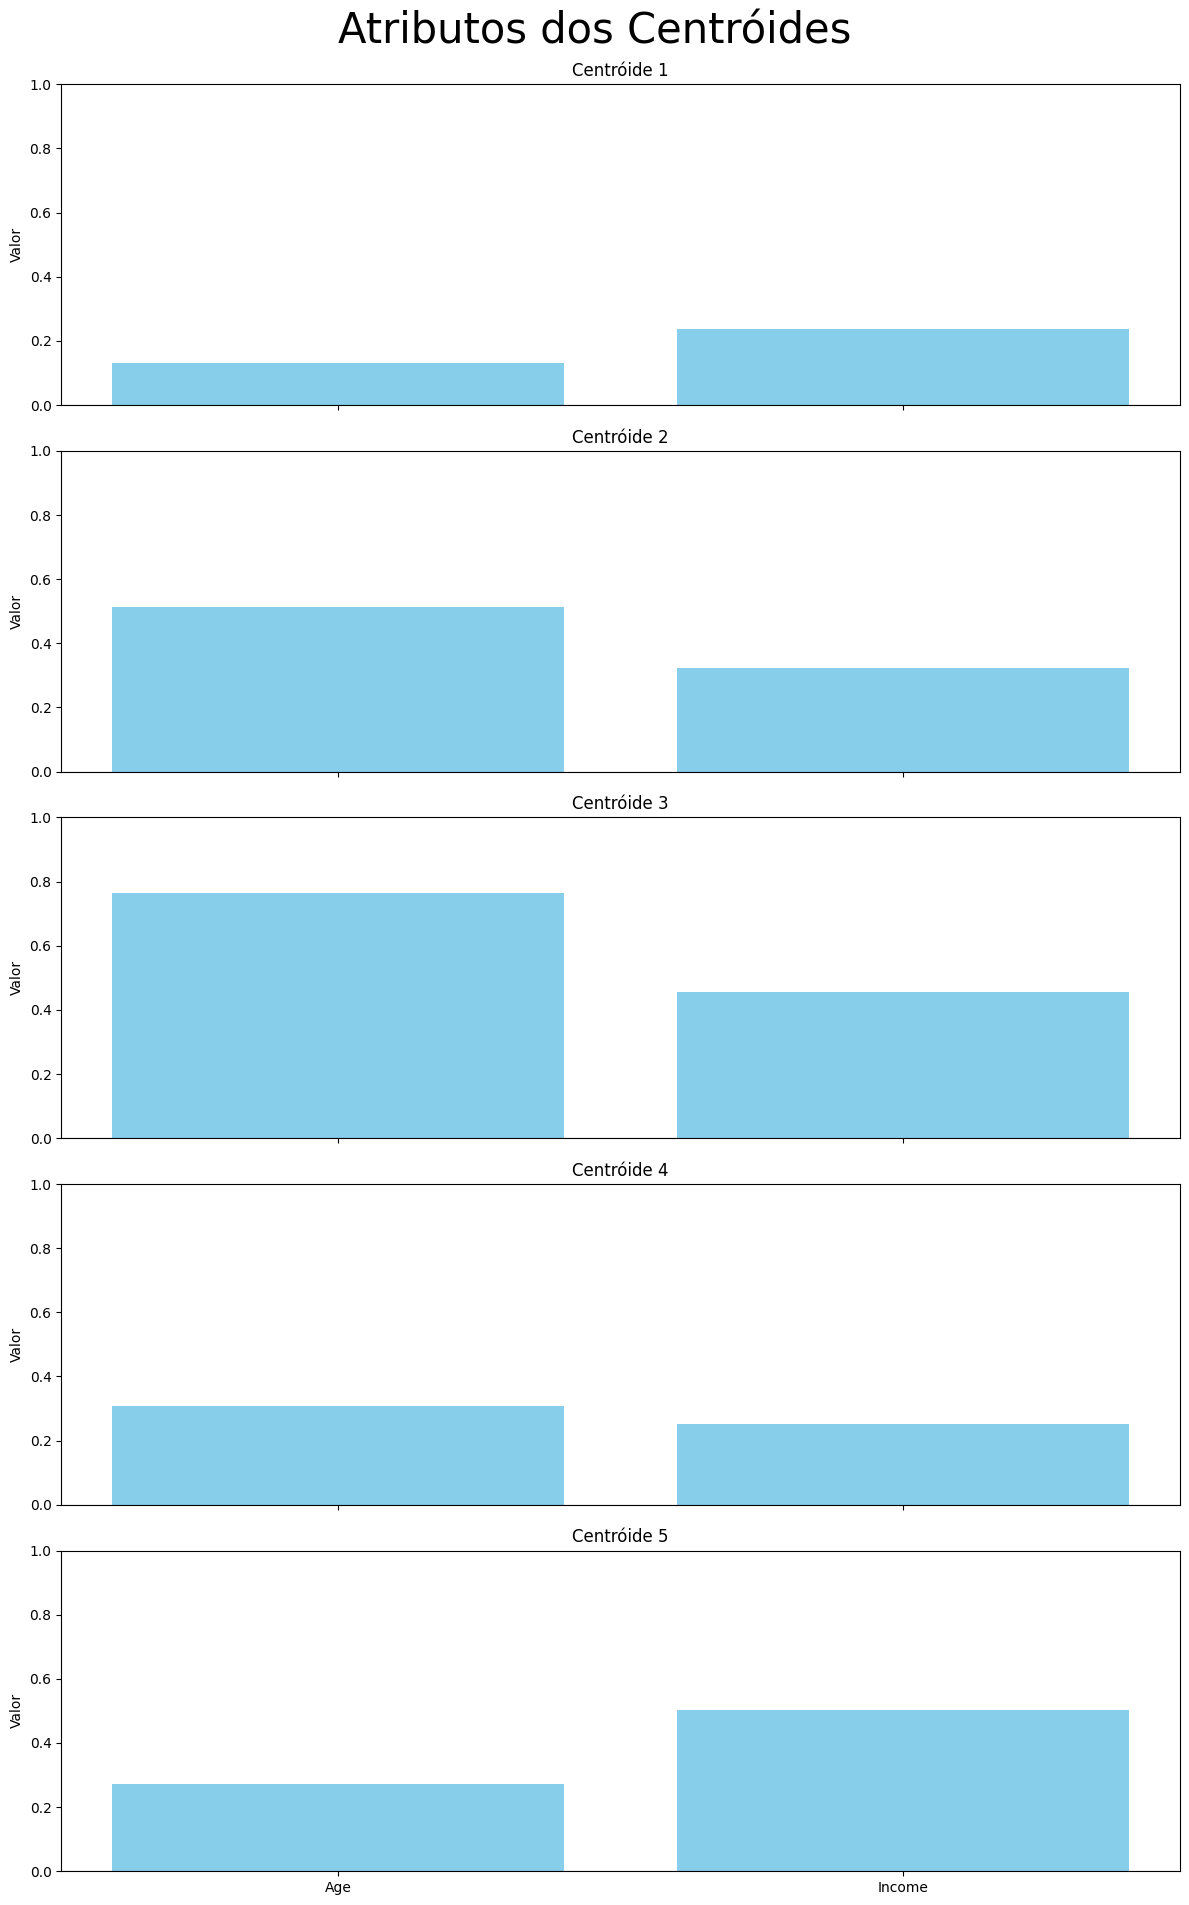

In [43]:
# Criando figura
fig, axes = plt.subplots(n_clusters, 1, figsize=(12, 4 * n_clusters), sharex=True)
fig.suptitle('Atributos dos Centróides', fontsize=30)

# Colocando os centroides no gráfico
for i, centroid in enumerate(centroids):
    ax = axes[i]
    ax.bar(cols_selected, centroid, color='skyblue')
    ax.set_title(f'Centróide {i+1}')
    ax.set_ylabel('Valor')
    ax.set_ylim(0, 1) # Fixa o eixo vertical entre 0 e 1
    ax.axhline(0, color='grey', linewidth=0.8) # Linha de referência para o zero

plt.tight_layout(rect=[0, 0.03, 1, 0.99]) # Ajustar layout para título superior
plt.show()